# T96 Model Analysis Using the 9 Directional Derivative Formulas

This notebook analyzes the 9 directional derivative formulas for the Tsyganenko 96 (T96) magnetospheric field model during moderate storm conditions. Unlike the pure dipole field, the T96 model includes:
- External current systems (magnetopause, ring current, tail currents)
- Response to solar wind parameters
- Non-planar field lines with significant torsion
- Complex 3D field topology

## Storm Parameters

We simulate moderate geomagnetic storm conditions:
- **Pdyn** = 4.0 nPa (solar wind dynamic pressure, elevated)
- **Dst** = -60 nT (storm-time disturbance index, moderate storm)
- **ByIMF** = 3.0 nT (IMF By component, southward)
- **BzIMF** = -5.0 nT (IMF Bz component, strongly southward)

## The 9 Key Formulas

1. **(∂T/∂T)·n = κ** (curvature)
2. **(∂T/∂T)·b = 0**
3. **(∂n/∂T)·b = τ** (torsion)
4. **(∂T/∂n)·n**
5. **(∂T/∂n)·b**
6. **(∂n/∂n)·b**
7. **(∂n/∂b)·b**
8. **(∂n/∂b)·T**
9. **(∂b/∂b)·T**

These formulas satisfy antisymmetry relations and provide a complete description of the field line geometry.

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Import geopack functions
from geopack import recalc, dip
from geopack.vectorized import (
    t96_vectorized,
    field_line_curvature_vectorized,
    field_line_torsion_vectorized,
    field_line_directional_derivatives_vectorized,
    verify_antisymmetry_relations,
    get_curvature_torsion_from_derivatives
)

# Set up time and storm parameters
ut = 0.0#5000.0+90.0*24.0*60.0*60.0  # Example time in seconds since epoch
ps = recalc(ut)
print(f"Dipole tilt angle: {np.degrees(ps):.2f} degrees")

# Define moderate storm parameters for T96
# [Pdyn, Dst, ByIMF, BzIMF, unused...]
density = 10*1e6  # cm^-3 to m^-3
velocity = 600.0e3  # km/s to m/s
Pdyn = 1.6726219e-27 * density * velocity**2 / 1e-9  # Convert to nPa
print(f"Calculated Pdyn: {Pdyn:.2f} nPa")
parmod = [
    Pdyn,   # Pdyn: Solar wind dynamic pressure (nPa) - elevated
    -30.0, # Dst: Storm-time disturbance index (nT) - moderate storm
    0.0,   # ByIMF: IMF By component (nT) - duskward
    -5.0,  # BzIMF: IMF Bz component (nT) - strongly southward
    0, 0, 0, 0, 0, 0  # Unused parameters
]

print("\nT96 Model Parameters (Moderate Storm):")
print(f"  Pdyn  = {parmod[0]:.1f} nPa (elevated)")
print(f"  Dst   = {parmod[1]:.1f} nT (moderate storm)")
print(f"  ByIMF = {parmod[2]:.1f} nT (duskward)")
print(f"  BzIMF = {parmod[3]:.1f} nT (strongly southward)")
print("\nExpected storm effects:")
print("  - Compressed magnetopause")
print("  - Enhanced ring current")
print("  - Stretched tail configuration")
print("  - Non-planar field lines with significant torsion")

Dipole tilt angle: -26.30 degrees
Calculated Pdyn: 6.02 nPa

T96 Model Parameters (Moderate Storm):
  Pdyn  = 6.0 nPa (elevated)
  Dst   = -30.0 nT (moderate storm)
  ByIMF = 0.0 nT (duskward)
  BzIMF = -5.0 nT (strongly southward)

Expected storm effects:
  - Compressed magnetopause
  - Enhanced ring current
  - Stretched tail configuration
  - Non-planar field lines with significant torsion


## Create Analysis Grid

We'll analyze the T96 field in two planes:
1. **Meridional plane** (X-Z plane at Y=0): Shows noon-midnight asymmetry
2. **Equatorial plane** (X-Y plane at Z=0): Shows dawn-dusk asymmetry from ByIMF

In [105]:
# Create grids for analysis
# Meridional plane (noon-midnight)
x_mer = np.linspace(-8, 4, 60)
z_mer = np.linspace(-4, 4, 50)
X_mer, Z_mer = np.meshgrid(x_mer, z_mer)
Y_mer = np.zeros_like(X_mer)

# Equatorial plane
x_eq = np.linspace(-8, 4, 60)
y_eq = np.linspace(-10, 10, 60)
X_eq, Y_eq = np.meshgrid(x_eq, y_eq)
Z_eq = np.zeros_like(X_eq)

# Flatten for vectorized calculations
x_mer_flat = X_mer.flatten()
y_mer_flat = Y_mer.flatten()
z_mer_flat = Z_mer.flatten()

x_eq_flat = X_eq.flatten()
y_eq_flat = Y_eq.flatten()
z_eq_flat = Z_eq.flatten()

print(f"Meridional plane grid: {X_mer.shape}")
print(f"Equatorial plane grid: {X_eq.shape}")

Meridional plane grid: (50, 60)
Equatorial plane grid: (60, 60)


## Calculate T96 Field Properties

In [106]:
# Define a wrapper for T96 field that includes dipole + external
def t96_field_wrapper(parmod, ps, x, y, z):
    """Wrapper for T96 field that matches expected interface."""
    bx_ex, by_ex, bz_ex = t96_vectorized(parmod, ps, x, y, z)
    bx_in, by_in, bz_in = dip(x, y, z)
    return bx_ex+bx_in, by_ex+by_in, bz_ex+bz_in

# Calculate all 9 directional derivatives for meridional plane
print("Calculating directional derivatives for meridional plane...")
derivatives_mer = field_line_directional_derivatives_vectorized(
    t96_field_wrapper, parmod, ps, x_mer_flat, y_mer_flat, z_mer_flat, delta = 1e-5
)

delta_min = 1e-5
print(f"Using delta = {delta_min:e} Re for directional derivatives")

# Extract curvature and torsion
curvature_mer, torsion_mer = get_curvature_torsion_from_derivatives(derivatives_mer)

# Reshape for plotting
curvature_mer_grid = curvature_mer.reshape(X_mer.shape)
torsion_mer_grid = torsion_mer.reshape(X_mer.shape)

print(f"Curvature range: {curvature_mer.min():.3f} to {curvature_mer.max():.3f} 1/Re")
print(f"Torsion range: {torsion_mer.min():.3e} to {torsion_mer.max():.3e} 1/Re")
print("Note: Torsion is non-zero for T96 (unlike pure dipole)")

Calculating directional derivatives for meridional plane...
Using delta = 1.000000e-05 Re for directional derivatives
Curvature range: 0.000 to 18.448 1/Re
Torsion range: -5.164e-04 to 3.847e-04 1/Re
Note: Torsion is non-zero for T96 (unlike pure dipole)


## Calculate All Nine Directional Derivative Parameters

In [107]:
# Reshape all 9 parameters for visualization
params = {}
# Main 9 formulas
for key in ['dT_dT_n', 'dT_dT_b', 'dn_dT_b', 'dT_dn_n', 'dT_dn_b', 
            'dn_dn_b', 'dn_db_b', 'dn_db_T', 'db_db_T']:
    arr = derivatives_mer[key].reshape(X_mer.shape)
    arr[np.abs(arr) < delta_min] = 0
    params[key] = arr

# Also add antisymmetric counterparts for verification
for key in ['dn_dT_T', 'db_dT_T', 'db_dT_n', 'dn_dn_T', 'db_dn_T', 
            'db_dn_n', 'db_db_n', 'dT_db_n', 'dT_db_b']:
    arr = derivatives_mer[key].reshape(X_mer.shape)
    arr[np.abs(arr) < delta_min] = 0
    params[key] = arr

# Verify antisymmetry
errors_mer = verify_antisymmetry_relations(derivatives_mer)

# Helper function for array errors
def get_max_error(error_val):
    if hasattr(error_val, 'shape'):
        return np.max(np.abs(error_val))
    else:
        return abs(error_val)

print("\nParameter summary:")
for key in ['dT_dT_n', 'dT_dT_b', 'dn_dT_b', 'dT_dn_n', 'dT_dn_b', 
            'dn_dn_b', 'dn_db_b', 'dn_db_T', 'db_db_T']:
    data = params[key]
    print(f"{key:12} range: [{data.min():8.3e}, {data.max():8.3e}]")

print("\nAntisymmetry verification (max errors):")
for name, error in errors_mer.items():
    max_error = get_max_error(error)
    print(f"{name:20} = {max_error:.2e}")


Parameter summary:
dT_dT_n      range: [0.000e+00, 1.845e+01]
dT_dT_b      range: [0.000e+00, 0.000e+00]
dn_dT_b      range: [-5.164e-04, 3.847e-04]
dT_dn_n      range: [-1.501e+01, 1.464e+01]
dT_dn_b      range: [0.000e+00, 0.000e+00]
dn_dn_b      range: [-1.108e-03, 1.705e-04]
dn_db_b      range: [-5.246e+01, 5.093e+03]
dn_db_T      range: [-2.486e-04, 7.845e-03]
db_db_T      range: [-9.397e+00, 1.308e+01]

Antisymmetry verification (max errors):
κ_check              = 5.76e-02
τ_check              = 1.83e-17
zero_check_1         = 0.00e+00
dT_dn_n_check        = 1.35e-02
dT_dn_b_check        = 0.00e+00
dn_dn_b_check        = 2.17e-15
dn_db_b_check        = 6.24e-07
dn_db_T_check        = 7.85e-03
db_db_T_check        = 5.08e-04


## Visualize All Nine Parameters in Meridional Plane

/tmp/ipykernel_8454/2372537736.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


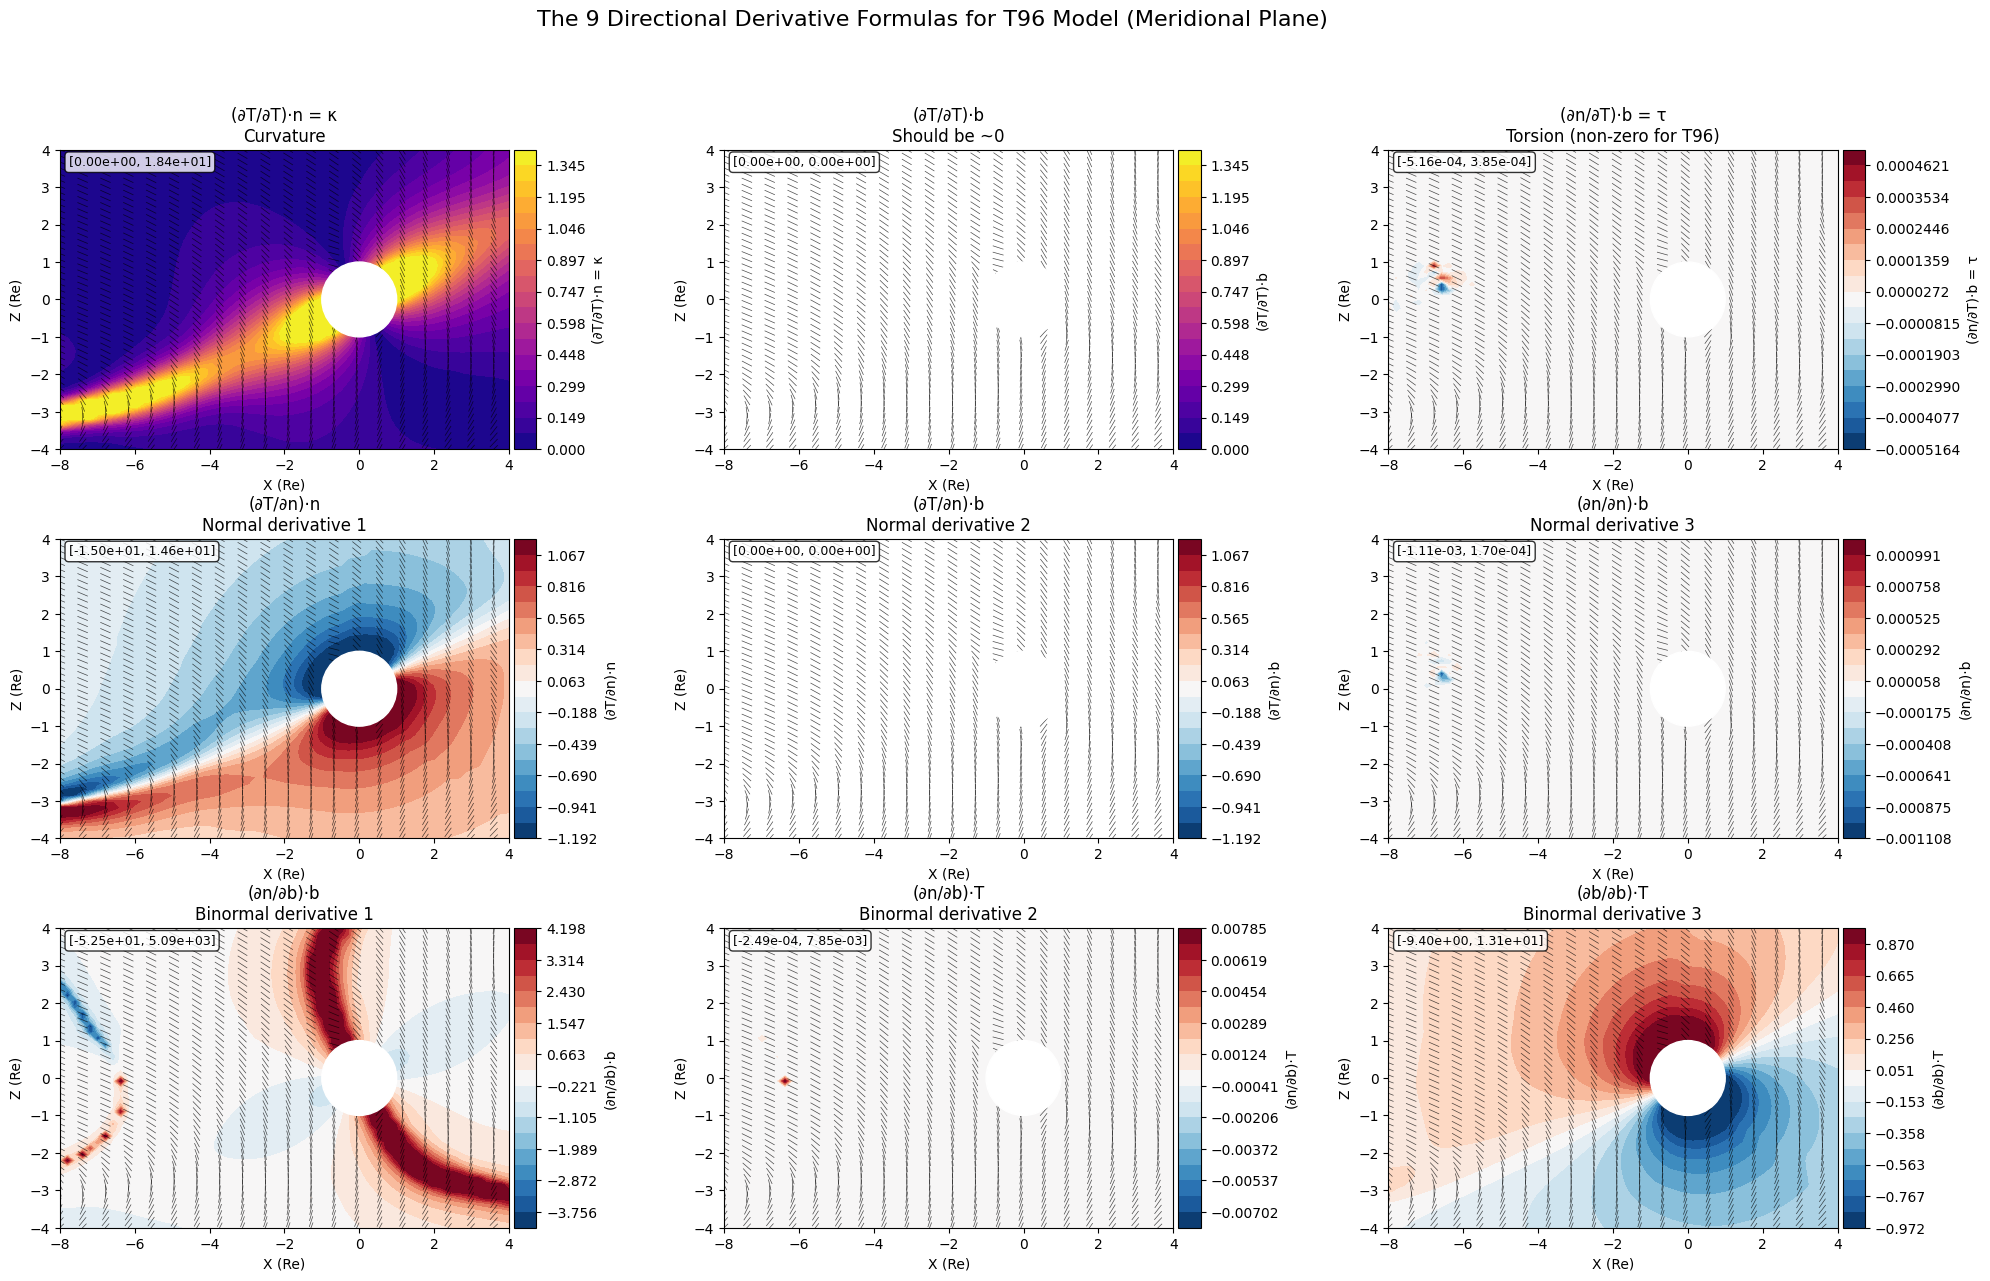

In [108]:
from matplotlib.collections import LineCollection

# Create figure with 9 subplots for the 9 formulas
fig = plt.figure(figsize=(24, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.25)

# Calculates magnetic field vectors on a meridional grid
Bx_mer, By_mer, Bz_mer = t96_vectorized(
    parmod, ps, X_mer, Y_mer, Z_mer
)

# --- ここで一度だけ「短い線分」のためのデータを作る -----------------
# ベクトルの大きさ（3成分全部を使う）
B_mag3 = np.sqrt(Bx_mer**2 + By_mer**2 + Bz_mer**2)

eps = 1e-12
B_mag3_safe = np.where(B_mag3 > eps, B_mag3, 1.0)

# 基準値（ユーザ指定の式の「基準値」に相当）
L0 = 0.3  # Re 単位。見た目に合わせて調整してください

# ここがご指定の形：
#   線分の x 成分長さ = 基準値 × Bx_mer / sqrt(Bx^2+By^2+Bz^2)
#   線分の z 成分長さ = 基準値 × Bz_mer / sqrt(Bx^2+By^2+Bz^2)
dx = L0 * Bx_mer / B_mag3_safe
dz = L0 * Bz_mer / B_mag3_safe

# 各格子点を中心とした線分の両端
x0 = X_mer - 0.5 * dx
z0 = Z_mer - 0.5 * dz
x1 = X_mer + 0.5 * dx
z1 = Z_mer + 0.5 * dz

# LineCollection 用に (N, 2, 2) 形状へ
segments = np.stack(
    [
        np.stack([x0, z0], axis=-1),
        np.stack([x1, z1], axis=-1)
    ],
    axis=2
)  # shape: (Ny, Nx, 2, 2)
segments = segments.reshape(-1, 2, 2)

# 密度を少し落としたいなら間引き（不要ならこの行は消してOK）
segments = segments[::3]
# ------------------------------------------------------------

# Parameter names and expected behaviors
plot_info = [
    ('dT_dT_n', '(∂T/∂T)·n = κ', 'Curvature', 'plasma'),
    ('dT_dT_b', '(∂T/∂T)·b', 'Should be ~0', 'RdBu_r'),
    ('dn_dT_b', '(∂n/∂T)·b = τ', 'Torsion (non-zero for T96)', 'RdBu_r'),
    ('dT_dn_n', '(∂T/∂n)·n', 'Normal derivative 1', 'RdBu_r'),
    ('dT_dn_b', '(∂T/∂n)·b', 'Normal derivative 2', 'RdBu_r'),
    ('dn_dn_b', '(∂n/∂n)·b', 'Normal derivative 3', 'RdBu_r'),
    ('dn_db_b', '(∂n/∂b)·b', 'Binormal derivative 1', 'RdBu_r'),
    ('dn_db_T', '(∂n/∂b)·T', 'Binormal derivative 2', 'RdBu_r'),
    ('db_db_T', '(∂b/∂b)·T', 'Binormal derivative 3', 'RdBu_r')
]

vlim_dict = {
    'dT_dT_n': (None, None),  
    'dT_dT_b': (None, None),
    'dn_dT_b': (None, None),
    'dT_dn_n': (None, None),
    'dT_dn_b': (None, None),
    'dn_dn_b': (None, None),
    'dn_db_b': (None, None), 
    'dn_db_T': (None, None),
    'db_db_T': (None, None),
}

for idx, (param_name, formula, title, cmap) in enumerate(plot_info):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    
    # Get data
    data = params[param_name]
    
    user_vmin, user_vmax = vlim_dict.get(param_name, (None, None))
    
    if (user_vmin is not None) and (user_vmax is not None):
        vmin, vmax = user_vmin, user_vmax
    else:
        if param_name == 'dT_dT_n':  # Curvature is always positive
            vmin, vmax = 0, np.percentile(data, 95)
        else:
            vmax = np.percentile(np.abs(data), 95)
            if vmax < 1e-15:
                vmax = np.max(np.abs(data))
            vmin = -vmax
    
    data_for_plot = np.clip(data, vmin, vmax)

    if vmin != vmax:
        levels = np.linspace(vmin, vmax, 20)
        
        im = ax.contourf(
            X_mer, Z_mer, data_for_plot,
            levels=levels,
            cmap=cmap,
            vmin=vmin, vmax=vmax
        )
            
    # --- streamplot の代わりに微小線群を描画 ----------------
    lc = LineCollection(
        segments,
        colors='k',
        linewidths=0.5,
        alpha=0.7
    )
    ax.add_collection(lc)
    # -------------------------------------------------------

    # Add Earth
    circle = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax.add_patch(circle)
    
    # Labels and formatting
    ax.set_xlabel('X (Re)')
    ax.set_ylabel('Z (Re)')
    ax.set_title(f'{formula}\n{title}', fontsize=12)
    ax.set_aspect('equal')

    ax.set_xlim(X_mer.min(), X_mer.max())
    ax.set_ylim(Z_mer.min(), Z_mer.max())
    
    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label(formula, fontsize=10)
    
    # Add text with range
    range_text = f"[{data.min():.2e}, {data.max():.2e}]"
    ax.text(0.02, 0.98, range_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('The 9 Directional Derivative Formulas for T96 Model (Meridional Plane)', fontsize=16)
plt.tight_layout()
plt.show()


## Visualize All Nine Parameters in Equational Plane

Calculating directional derivatives for equatorial plane...


/tmp/ipykernel_8454/3150835316.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


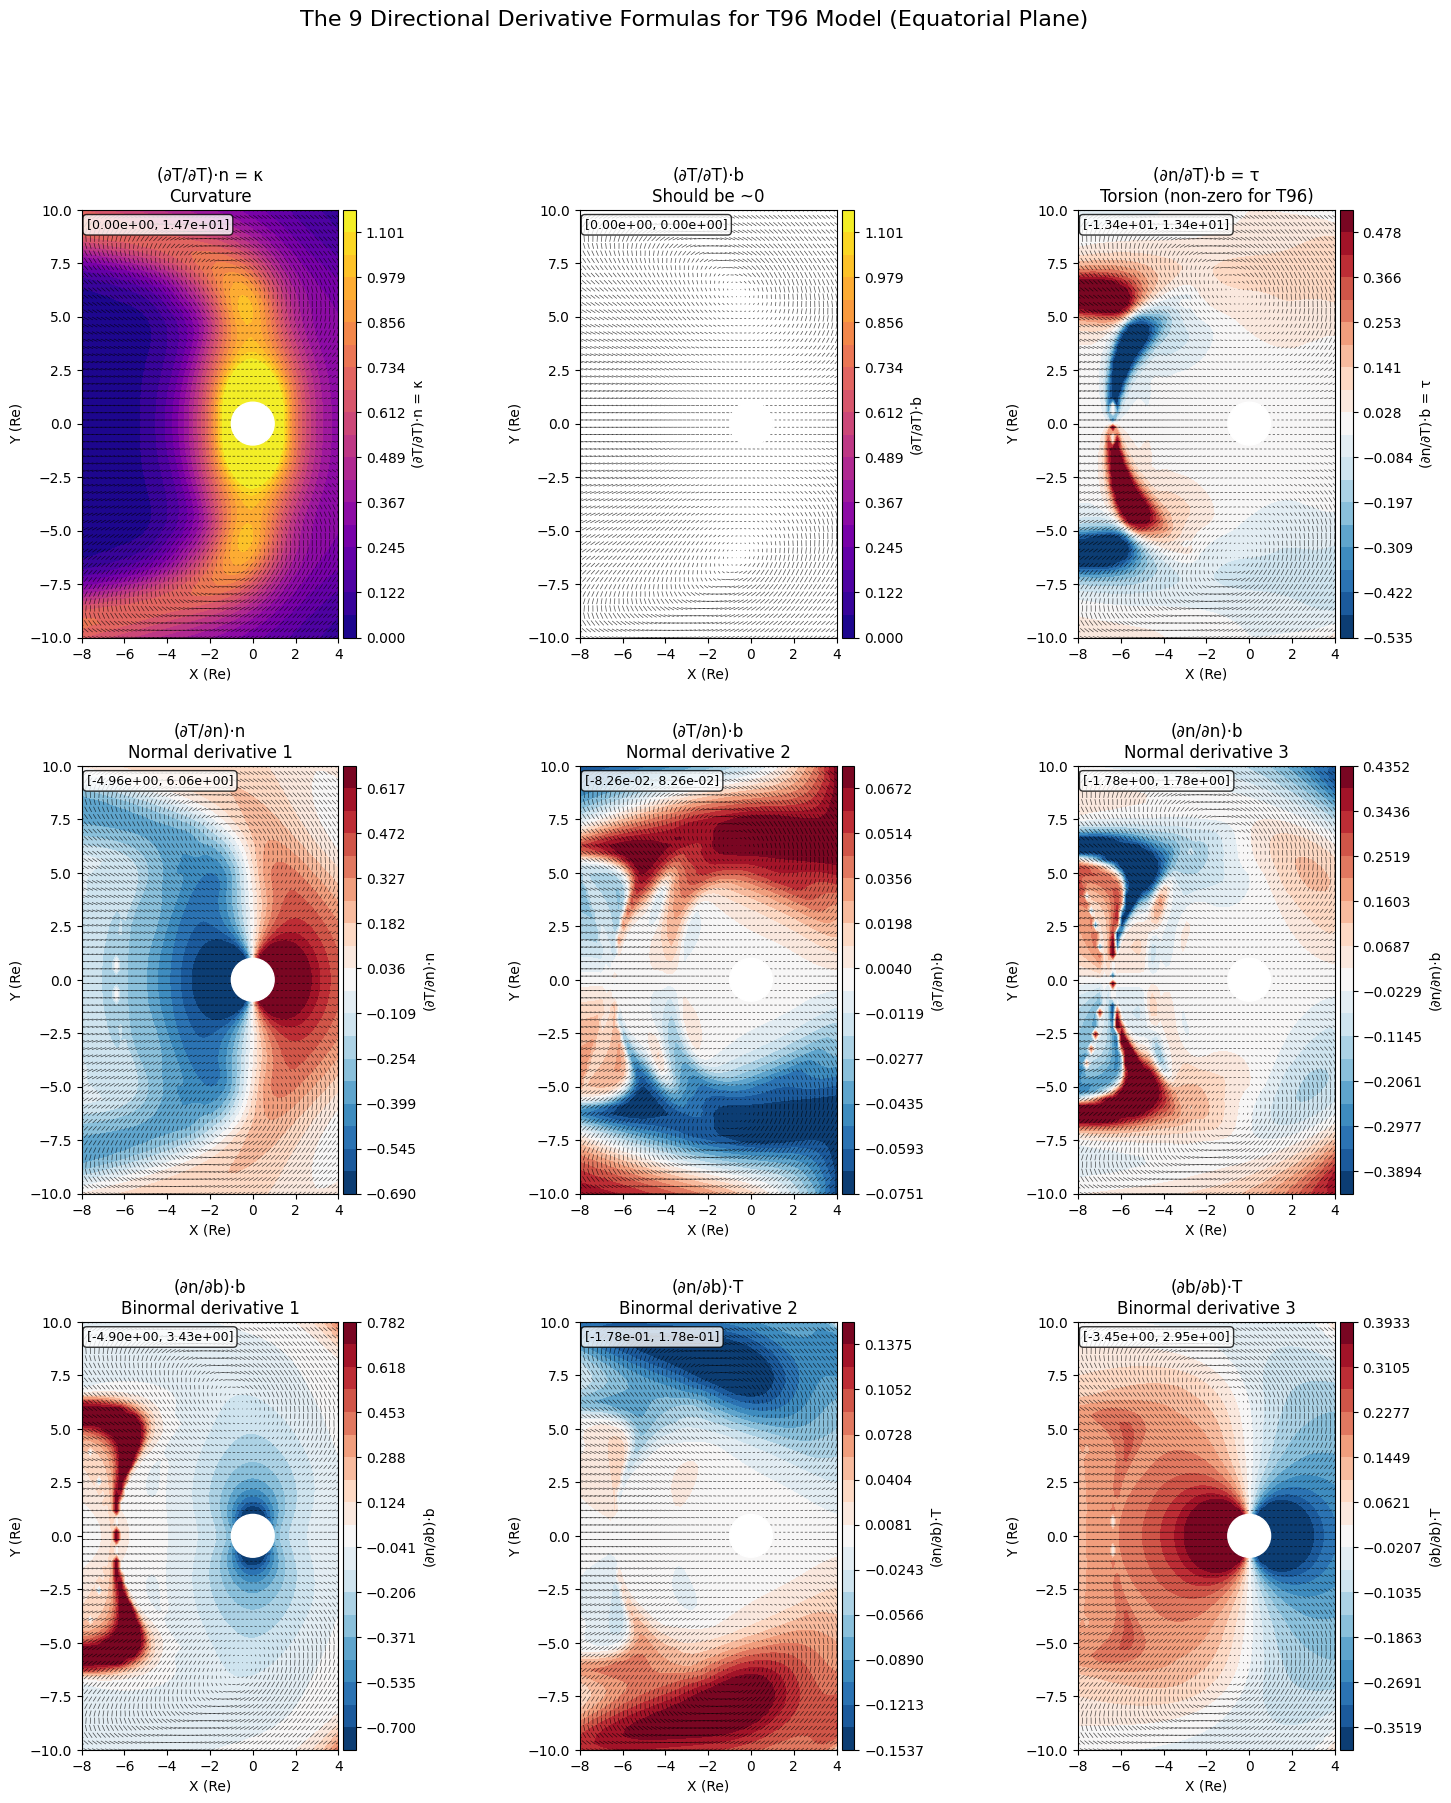

In [109]:
# Create figure with 9 subplots for the 9 formulas
fig = plt.figure(figsize=(18, 20))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.25)

# Calculates magnetic field vectors on an equatorial grid
Bx_eq, By_eq, Bz_eq = t96_vectorized(
    parmod, ps, X_eq, Y_eq, Z_eq
)

# --- ここで一度だけ「短い線分」のためのデータを作る -----------------
# ベクトルの大きさ（3成分全部を使用）
B_mag3 = np.sqrt(Bx_eq**2 + By_eq**2 + Bz_eq**2)

eps = 1e-12
B_mag3_safe = np.where(B_mag3 > eps, B_mag3, 1.0)

# 基準値（線分の全長のスケール）
L0 = 0.3  # Re 単位。見た目で調整

# ご指定の形：
#   線分の x 成分長さ = 基準値 × Bx_eq / sqrt(Bx^2+By^2+Bz^2)
#   線分の y 成分長さ = 基準値 × By_eq / sqrt(Bx^2+By^2+Bz^2)
dx = L0 * Bx_eq / B_mag3_safe
dy = L0 * By_eq / B_mag3_safe

# 各格子点を中心とした線分の両端
x0 = X_eq - 0.5 * dx
y0 = Y_eq - 0.5 * dy
x1 = X_eq + 0.5 * dx
y1 = Y_eq + 0.5 * dy

# LineCollection 用に (N, 2, 2) 形状へ
segments = np.stack(
    [
        np.stack([x0, y0], axis=-1),
        np.stack([x1, y1], axis=-1)
    ],
    axis=2
)  # shape: (Ny, Nx, 2, 2)
segments = segments.reshape(-1, 2, 2)

# 密度を落としたければ間引き（不要ならこの行を削除）
# segments = segments[::2]
# ------------------------------------------------------------


# Calculate derivatives for equatorial plane
print("Calculating directional derivatives for equatorial plane...")
derivatives_eq = field_line_directional_derivatives_vectorized(
    t96_field_wrapper, parmod, ps, x_eq_flat, y_eq_flat, z_eq_flat
)

params_eq = {}
# Main 9 formulas
for key in ['dT_dT_n', 'dT_dT_b', 'dn_dT_b', 'dT_dn_n', 'dT_dn_b', 
            'dn_dn_b', 'dn_db_b', 'dn_db_T', 'db_db_T']:
    arr = derivatives_eq[key].reshape(X_eq.shape)
    arr[np.abs(arr) < delta_min] = 0
    params_eq[key] = arr

# Also add antisymmetric counterparts for verification
for key in ['dn_dT_T', 'db_dT_T', 'db_dT_n', 'dn_dn_T', 'db_dn_T', 
            'db_dn_n', 'db_db_n', 'dT_db_n', 'dT_db_b']:
    arr = derivatives_eq[key].reshape(X_eq.shape)
    arr[np.abs(arr) < delta_min] = 0
    params_eq[key] = arr

# Parameter names and expected behaviors
plot_info = [
    ('dT_dT_n', '(∂T/∂T)·n = κ', 'Curvature', 'plasma'),
    ('dT_dT_b', '(∂T/∂T)·b', 'Should be ~0', 'RdBu_r'),
    ('dn_dT_b', '(∂n/∂T)·b = τ', 'Torsion (non-zero for T96)', 'RdBu_r'),
    ('dT_dn_n', '(∂T/∂n)·n', 'Normal derivative 1', 'RdBu_r'),
    ('dT_dn_b', '(∂T/∂n)·b', 'Normal derivative 2', 'RdBu_r'),
    ('dn_dn_b', '(∂n/∂n)·b', 'Normal derivative 3', 'RdBu_r'),
    ('dn_db_b', '(∂n/∂b)·b', 'Binormal derivative 1', 'RdBu_r'),
    ('dn_db_T', '(∂n/∂b)·T', 'Binormal derivative 2', 'RdBu_r'),
    ('db_db_T', '(∂b/∂b)·T', 'Binormal derivative 3', 'RdBu_r')
]
vlim_dict = {
    'dT_dT_n': (None, None), 
    'dT_dT_b': (None, None),
    'dn_dT_b': (None, None),
    'dT_dn_n': (None, None),
    'dT_dn_b': (None, None),
    'dn_dn_b': (None, None),
    'dn_db_b': (None, None),
    'dn_db_T': (None, None),
    'db_db_T': (None, None),
}

for idx, (param_name, formula, title, cmap) in enumerate(plot_info):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    
    # Get data
    data = params_eq[param_name]
    
    user_vmin, user_vmax = vlim_dict.get(param_name, (None, None))
    
    if (user_vmin is not None) and (user_vmax is not None):
        vmin, vmax = user_vmin, user_vmax
    else:
        if param_name == 'dT_dT_n':  # Curvature is always positive
            vmin, vmax = 0, np.percentile(data, 95)
        else:
            vmax = np.percentile(np.abs(data), 95)
            if vmax < 1e-15:
                vmax = np.max(np.abs(data))
            vmin = -vmax
    
    data_for_plot = np.clip(data, vmin, vmax)
    
    if vmin != vmax:
        levels = np.linspace(vmin, vmax, 20)
        im = ax.contourf(
            X_eq, Y_eq, data_for_plot,
            levels=levels,
            cmap=cmap,
            vmin=vmin, vmax=vmax
        )
        
    # --- streamplot の代わりに「微小な線」をたくさん描画 ----------
    lc = LineCollection(
        segments,
        colors='k',
        linewidths=0.5,
        alpha=0.7
    )
    ax.add_collection(lc)
    # -----------------------------------------------------------

    # Add Earth
    circle = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax.add_patch(circle)
    
    # Labels and formatting
    ax.set_xlabel('X (Re)')
    ax.set_ylabel('Y (Re)')
    ax.set_title(f'{formula}\n{title}', fontsize=12)
    ax.set_aspect('equal')

    ax.set_xlim(X_eq.min(), X_eq.max())
    ax.set_ylim(Y_eq.min(), Y_eq.max())
    
    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label(formula, fontsize=10)
    
    # Add text with range
    range_text = f"[{data.min():.2e}, {data.max():.2e}]"
    ax.text(0.02, 0.98, range_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('The 9 Directional Derivative Formulas for T96 Model (Equatorial Plane)', fontsize=16)
plt.tight_layout()
plt.show()


## Compare Curvature and Torsion Patterns

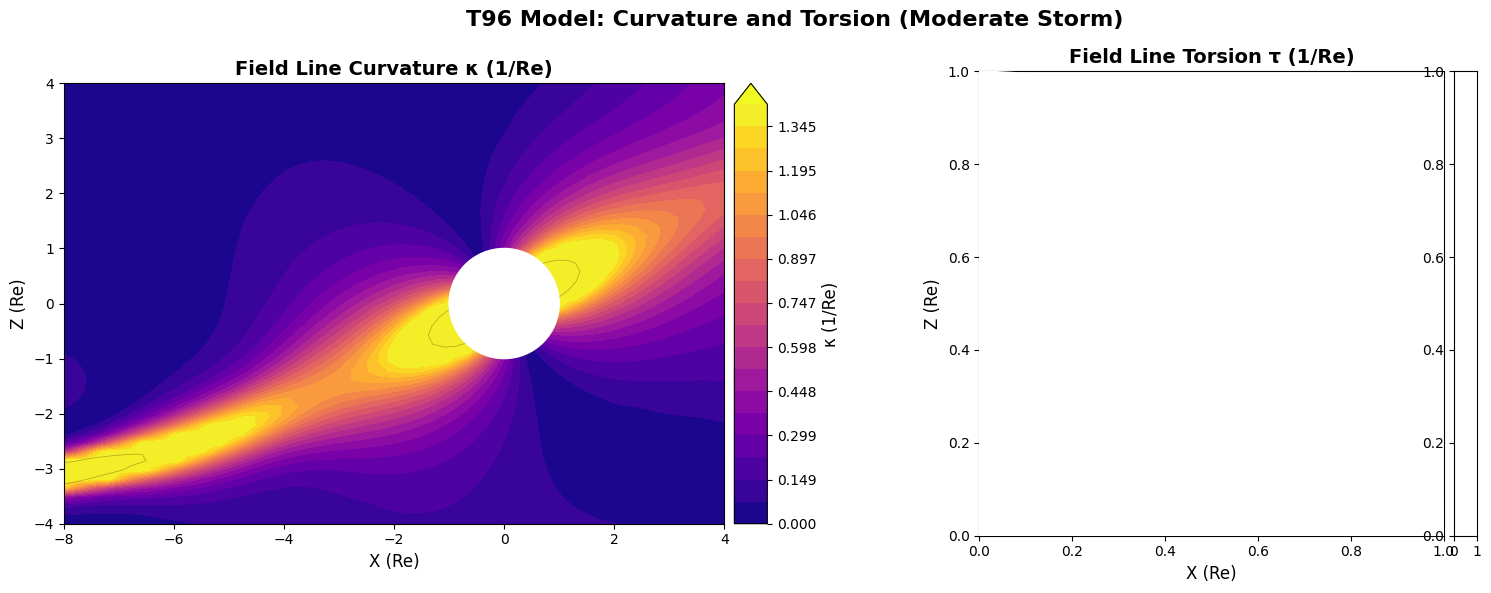


Curvature statistics:
  Min:    0.000 1/Re
  Max:    18.448 1/Re
  Mean:   0.388 1/Re
  Median: 0.138 1/Re

Torsion statistics:
  Min:    -5.164e-04 1/Re
  Max:    3.847e-04 1/Re
  Mean:   -1.917e-07 1/Re
  Median: 0.000e+00 1/Re

Note: Non-zero torsion indicates 3D field line structure


In [110]:
# Create detailed plots of curvature and torsion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curvature
ax = axes[0]
vmax_curv = np.percentile(curvature_mer_grid, 95)
data_for_plot = np.clip(curvature_mer_grid, 0, vmax_curv)
levels = np.linspace(0, vmax_curv, 20)
im1 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='plasma', 
                  vmin=0, vmax=vmax_curv, extend='max')
ax.contour(X_mer, Z_mer, curvature_mer_grid, levels=10, colors='black', 
           alpha=0.3, linewidths=0.5)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_xlabel('X (Re)', fontsize=12)
ax.set_ylabel('Z (Re)', fontsize=12)
ax.set_title('Field Line Curvature κ (1/Re)', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar1 = plt.colorbar(im1, cax=cax)
cbar1.set_label('κ (1/Re)', fontsize=12)

# Torsion
ax = axes[1]
vmax_tors = np.percentile(np.abs(torsion_mer_grid), 95)
data_for_plot = np.clip(torsion_mer_grid, -vmax_tors, vmax_tors)
if(vmax_tors != 0):
    levels = np.linspace(-vmax_tors, vmax_tors, 20)
    im2 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='RdBu_r', 
                    vmin=-vmax_tors, vmax=vmax_tors)
    ax.contour(X_mer, Z_mer, torsion_mer_grid, levels=10, colors='black', 
            alpha=0.3, linewidths=0.5)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_xlabel('X (Re)', fontsize=12)
ax.set_ylabel('Z (Re)', fontsize=12)
ax.set_title('Field Line Torsion τ (1/Re)', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
if(vmax_tors != 0):
    cbar2 = plt.colorbar(im2, cax=cax)
    cbar2.set_label('τ (1/Re)', fontsize=12)

plt.suptitle('T96 Model: Curvature and Torsion (Moderate Storm)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nCurvature statistics:")
print(f"  Min:    {curvature_mer.min():.3f} 1/Re")
print(f"  Max:    {curvature_mer.max():.3f} 1/Re")
print(f"  Mean:   {curvature_mer.mean():.3f} 1/Re")
print(f"  Median: {np.median(curvature_mer):.3f} 1/Re")

print(f"\nTorsion statistics:")
print(f"  Min:    {torsion_mer.min():.3e} 1/Re")
print(f"  Max:    {torsion_mer.max():.3e} 1/Re")
print(f"  Mean:   {torsion_mer.mean():.3e} 1/Re")
print(f"  Median: {np.median(torsion_mer):.3e} 1/Re")
print(f"\nNote: Non-zero torsion indicates 3D field line structure")

## Verify Key Relationships

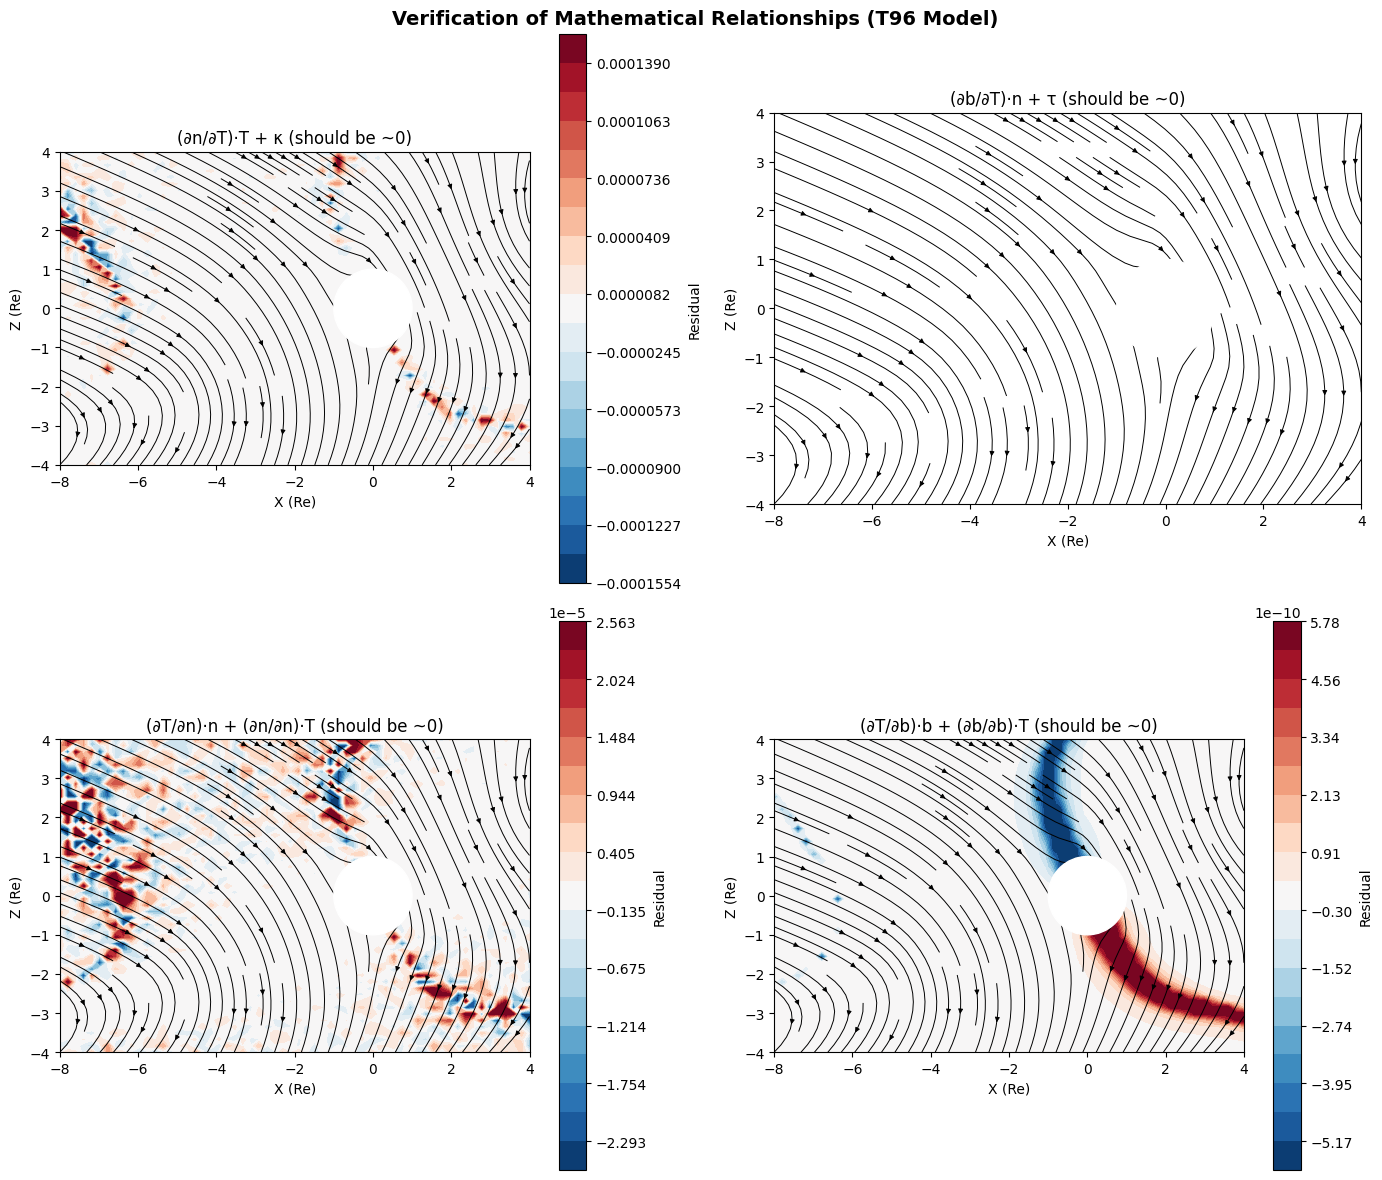

Quantitative Verification:
max|(∂n/∂T)·T + κ| = 5.757e-02
max|(∂b/∂T)·n + τ| = 1.830e-17
max|(∂T/∂n)·n + (∂n/∂n)·T| = 1.347e-02
max|(∂T/∂b)·b + (∂b/∂b)·T| = 5.077e-04

For comparison:
max|κ| = 18.448
max|τ| = 5.164e-04


In [111]:
# Verify expected relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Check (∂n/∂T)·T ≈ -κ (from antisymmetry)
ax = axes[0, 0]
# diff1 = params['dn_dT_T'] + curvature_mer_grid
diff1 = params['dn_dT_T'] + params['dT_dT_n']
vmax1 = np.percentile(np.abs(diff1), 99)
data_for_plot = np.clip(diff1, -vmax1, vmax1)
if(vmax1 != 0):
    levels = np.linspace(-vmax1, vmax1, 20)
    im1 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='RdBu_r', 
                    vmin=-vmax1, vmax=vmax1)
# Overlapping magnetic field streamlines (magnetic field lines)
strm = ax.streamplot(
    X_mer, Z_mer,
    Bx_mer, Bz_mer,      
    density=1.2,         
    linewidth=0.7,       
    color='k',           
    arrowsize=0.7        
)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('(∂n/∂T)·T + κ (should be ~0)', fontsize=12)
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')
if(vmax1 != 0):
    plt.colorbar(im1, ax=ax, label='Residual')

# 2. Check (∂b/∂T)·n = -τ
ax = axes[0, 1]
diff2 = params['db_dT_n'] + torsion_mer_grid
vmax2 = np.percentile(np.abs(diff2), 95)
data_for_plot = np.clip(diff2, -vmax2, vmax2)
levels = np.linspace(-vmax2, vmax2, 20)
if(vmax2 != 0):
    im2 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='RdBu_r',
                  vmin=-vmax2, vmax=vmax2)
# Overlapping magnetic field streamlines (magnetic field lines)
strm = ax.streamplot(
    X_mer, Z_mer,
    Bx_mer, Bz_mer,      
    density=1.2,         
    linewidth=0.7,       
    color='k',           
    arrowsize=0.7        
)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('(∂b/∂T)·n + τ (should be ~0)', fontsize=12)
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')
if(vmax2 != 0):
    plt.colorbar(im2, ax=ax, label='Residual')

# 3. Antisymmetry: (∂T/∂n)·n + (∂n/∂n)·T = 0
ax = axes[1, 0]
antisym1 = params['dT_dn_n'] + params['dn_dn_T']
vmax3 = np.percentile(np.abs(antisym1), 95)
data_for_plot = np.clip(antisym1, -vmax3, vmax3)
levels = np.linspace(-vmax3, vmax3, 20)
im3 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='RdBu_r',
                  vmin=-vmax3, vmax=vmax3)
# Overlapping magnetic field streamlines (magnetic field lines)
strm = ax.streamplot(
    X_mer, Z_mer,
    Bx_mer, Bz_mer,      
    density=1.2,         
    linewidth=0.7,       
    color='k',           
    arrowsize=0.7        
)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('(∂T/∂n)·n + (∂n/∂n)·T (should be ~0)', fontsize=12)
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')
plt.colorbar(im3, ax=ax, label='Residual')

# 4. Antisymmetry: (∂T/∂b)·b + (∂b/∂b)·T = 0
ax = axes[1, 1]
antisym2 = params['dT_db_b'] + params['db_db_T']
vmax4 = np.percentile(np.abs(antisym2), 95)
data_for_plot = np.clip(antisym2, -vmax4, vmax4)
levels = np.linspace(-vmax4, vmax4, 20)
im4 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='RdBu_r',
                  vmin=-vmax4, vmax=vmax4)
# Overlapping magnetic field streamlines (magnetic field lines)
strm = ax.streamplot(
    X_mer, Z_mer,
    Bx_mer, Bz_mer,      
    density=1.2,         
    linewidth=0.7,       
    color='k',           
    arrowsize=0.7        
)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('(∂T/∂b)·b + (∂b/∂b)·T (should be ~0)', fontsize=12)
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')
plt.colorbar(im4, ax=ax, label='Residual')

plt.suptitle('Verification of Mathematical Relationships (T96 Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print quantitative verification
print("Quantitative Verification:")
print("=" * 50)
print(f"max|(∂n/∂T)·T + κ| = {np.max(np.abs(diff1)):.3e}")
print(f"max|(∂b/∂T)·n + τ| = {np.max(np.abs(diff2)):.3e}")
print(f"max|(∂T/∂n)·n + (∂n/∂n)·T| = {np.max(np.abs(antisym1)):.3e}")
print(f"max|(∂T/∂b)·b + (∂b/∂b)·T| = {np.max(np.abs(antisym2)):.3e}")
print(f"\nFor comparison:")
print(f"max|κ| = {np.max(np.abs(curvature_mer_grid)):.3f}")
print(f"max|τ| = {np.max(np.abs(torsion_mer_grid)):.3e}")

## Analyze Equatorial Plane (Dawn-Dusk Asymmetry)

Calculating directional derivatives for equatorial plane...


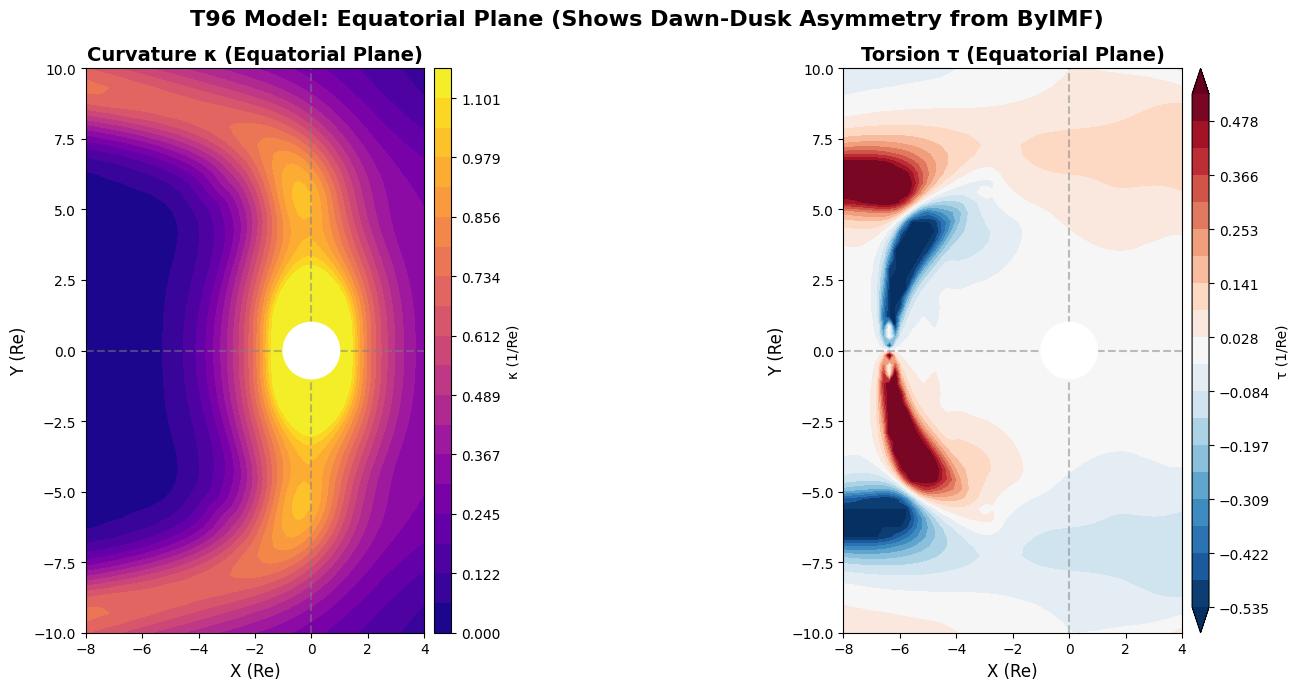


Equatorial plane statistics:
Curvature: [0.000, 14.722] 1/Re
Torsion:   [-1.341e+01, 1.341e+01] 1/Re


In [112]:
# Calculate derivatives for equatorial plane
print("Calculating directional derivatives for equatorial plane...")
derivatives_eq = field_line_directional_derivatives_vectorized(
    t96_field_wrapper, parmod, ps, x_eq_flat, y_eq_flat, z_eq_flat
)

# Extract curvature and torsion
curvature_eq, torsion_eq = get_curvature_torsion_from_derivatives(derivatives_eq)

# Reshape
curvature_eq_grid = curvature_eq.reshape(X_eq.shape)
torsion_eq_grid = torsion_eq.reshape(X_eq.shape)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Curvature in equatorial plane
ax = axes[0]
vmax_curv_eq = np.percentile(curvature_eq_grid, 95)
data_for_plot = np.clip(curvature_eq_grid, 0, vmax_curv_eq)
levels = np.linspace(0, vmax_curv_eq, 20)
im1 = ax.contourf(X_eq, Y_eq, data_for_plot, levels=levels, cmap='plasma',
                  vmin=0, vmax=vmax_curv_eq)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_xlabel('X (Re)', fontsize=12)
ax.set_ylabel('Y (Re)', fontsize=12)
ax.set_title('Curvature κ (Equatorial Plane)', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im1, cax=cax, label='κ (1/Re)')

# Torsion in equatorial plane
ax = axes[1]
vmax_tors_eq = np.percentile(np.abs(torsion_eq_grid), 95)
data_for_plot = np.clip(torsion_eq_grid, -vmax_tors_eq, vmax_tors_eq)
levels = np.linspace(-vmax_tors_eq, vmax_tors_eq, 20)
im2 = ax.contourf(X_eq, Y_eq, data_for_plot, levels=levels, cmap='RdBu_r',
                  vmin=-vmax_tors_eq, vmax=vmax_tors_eq, extend='both')
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_xlabel('X (Re)', fontsize=12)
ax.set_ylabel('Y (Re)', fontsize=12)
ax.set_title('Torsion τ (Equatorial Plane)', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im2, cax=cax, label='τ (1/Re)')

plt.suptitle('T96 Model: Equatorial Plane (Shows Dawn-Dusk Asymmetry from ByIMF)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nEquatorial plane statistics:")
print(f"Curvature: [{curvature_eq.min():.3f}, {curvature_eq.max():.3f}] 1/Re")
print(f"Torsion:   [{torsion_eq.min():.3e}, {torsion_eq.max():.3e}] 1/Re")

## Compare T96 Storm Effects with Dipole

Calculate the same quantities for a pure dipole to highlight storm-time modifications.

Calculating dipole field derivatives for comparison...


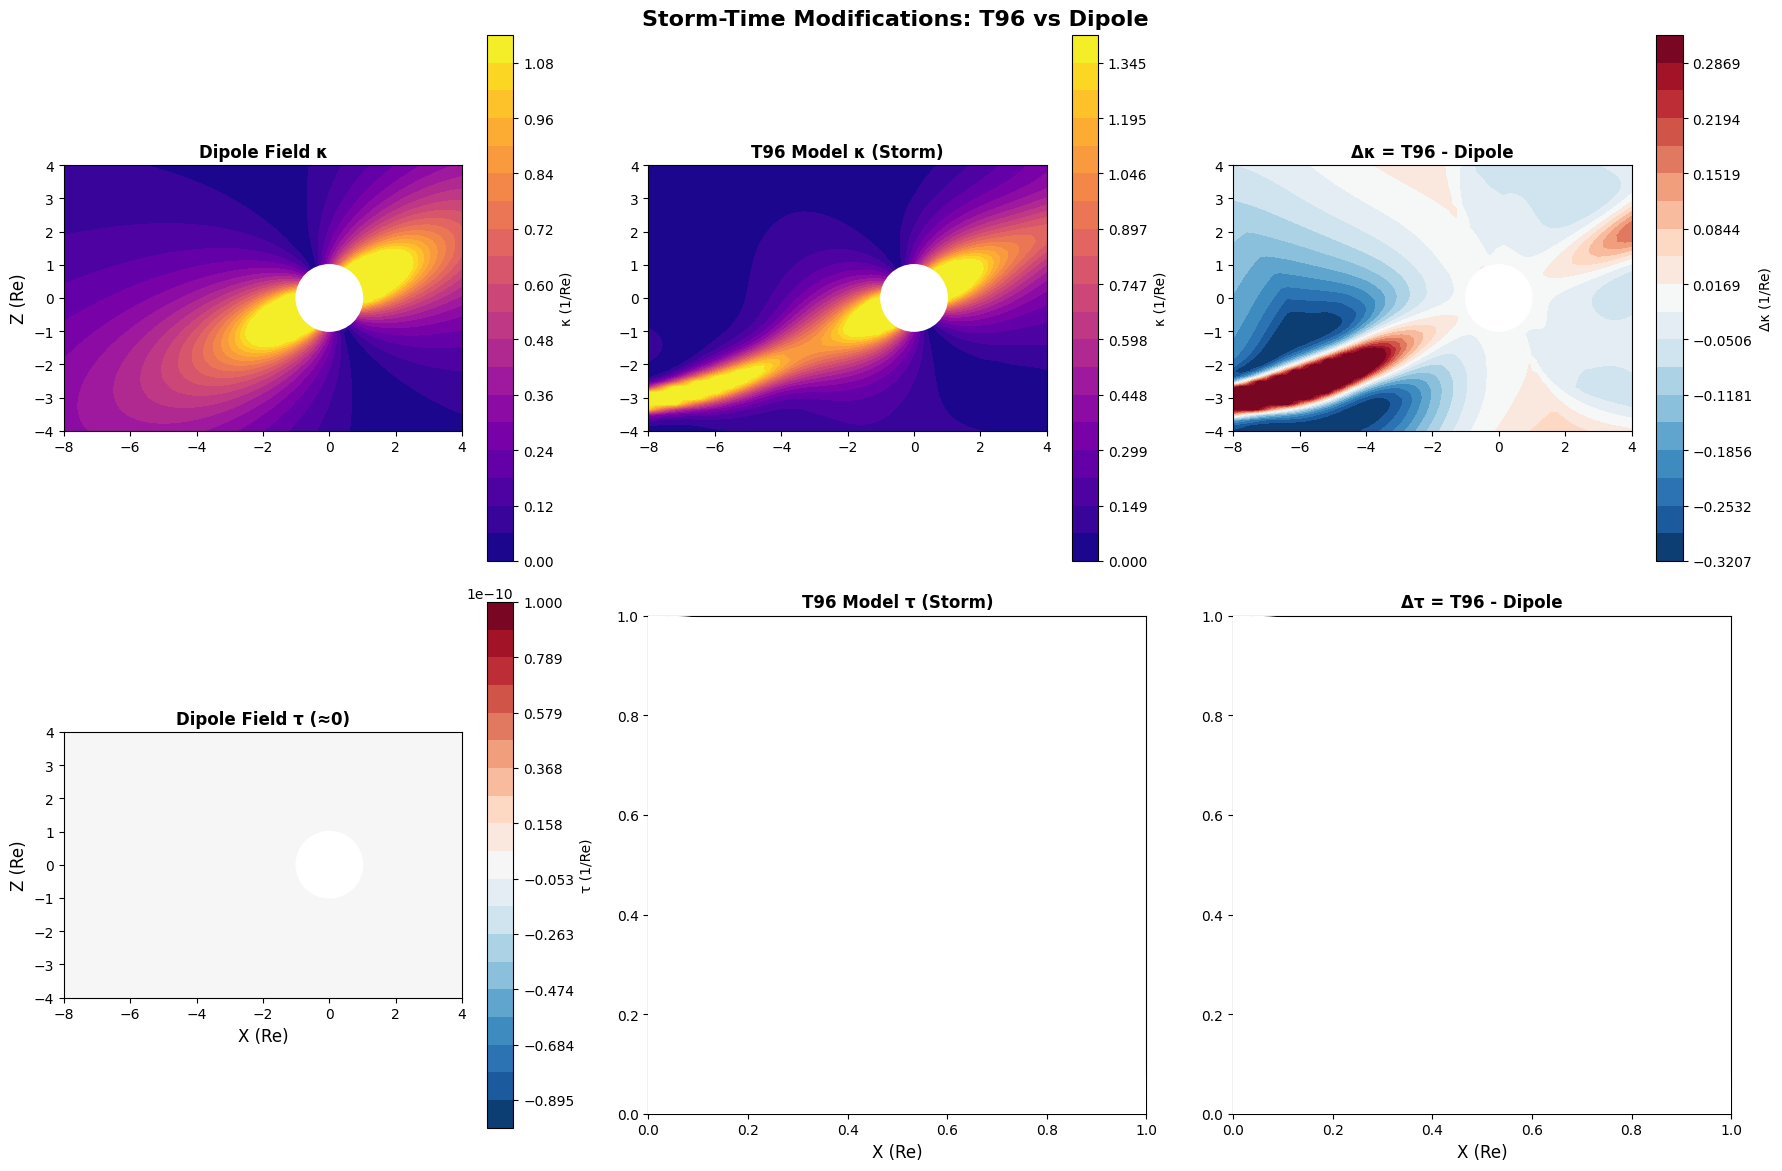


Storm-time modifications:
Curvature change: [-0.828, 16.452] 1/Re
Torsion change:   [-5.164e-04, 3.847e-04] 1/Re

RMS curvature change: 0.399 1/Re
RMS torsion change:   1.804e-05 1/Re


In [113]:
# Define dipole-only field wrapper
from geopack import dip

def dipole_field_wrapper(parmod, ps, x, y, z):
    """Wrapper for dipole field."""
    bx, by, bz = dip(x, y, z)
    return bx, by, bz

# Calculate dipole derivatives
print("Calculating dipole field derivatives for comparison...")
derivatives_dip = field_line_directional_derivatives_vectorized(
    dipole_field_wrapper, None, ps, x_mer_flat, y_mer_flat, z_mer_flat
)

curvature_dip, torsion_dip = get_curvature_torsion_from_derivatives(derivatives_dip)
curvature_dip_grid = curvature_dip.reshape(X_mer.shape)
torsion_dip_grid = torsion_dip.reshape(X_mer.shape)

# Calculate differences
delta_curvature = curvature_mer_grid - curvature_dip_grid
delta_torsion = torsion_mer_grid - torsion_dip_grid

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Curvature
# Dipole
ax = axes[0, 0]
vmax_dip = np.percentile(curvature_dip_grid, 95)
data_for_plot = np.clip(curvature_dip_grid, 0, vmax_dip)
levels = np.linspace(0, vmax_dip, 20)
im1 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='plasma',
                  vmin=0, vmax=vmax_dip)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('Dipole Field κ', fontsize=12, fontweight='bold')
ax.set_ylabel('Z (Re)', fontsize=12)
ax.set_aspect('equal')
plt.colorbar(im1, ax=ax, label='κ (1/Re)')

# T96
ax = axes[0, 1]
vmax_t96 = np.percentile(curvature_mer_grid, 95)
data_for_plot = np.clip(curvature_mer_grid, 0, vmax_t96)
levels = np.linspace(0, vmax_t96, 20)
im2 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='plasma',
                  vmin=0, vmax=vmax_t96)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('T96 Model κ (Storm)', fontsize=12, fontweight='bold')
ax.set_aspect('equal')
plt.colorbar(im2, ax=ax, label='κ (1/Re)')

# Difference
ax = axes[0, 2]
vmax_diff = np.percentile(np.abs(delta_curvature), 95)
data_for_plot = np.clip(delta_curvature, -vmax_diff, vmax_diff)
levels = np.linspace(-vmax_diff, vmax_diff, 20)
im3 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='RdBu_r',
                  vmin=-vmax_diff, vmax=vmax_diff)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('Δκ = T96 - Dipole', fontsize=12, fontweight='bold')
ax.set_aspect('equal')
plt.colorbar(im3, ax=ax, label='Δκ (1/Re)')

# Row 2: Torsion
# Dipole
ax = axes[1, 0]
vmax_dip_t = np.percentile(np.abs(torsion_dip_grid), 95)
if vmax_dip_t < 1e-10:
    vmax_dip_t = 1e-10
data_for_plot = np.clip(torsion_dip_grid, -vmax_dip_t, vmax_dip_t)
levels = np.linspace(-vmax_dip_t, vmax_dip_t, 20)
im4 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='RdBu_r',
                  vmin=-vmax_dip_t, vmax=vmax_dip_t)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('Dipole Field τ (≈0)', fontsize=12, fontweight='bold')
ax.set_xlabel('X (Re)', fontsize=12)
ax.set_ylabel('Z (Re)', fontsize=12)
ax.set_aspect('equal')
plt.colorbar(im4, ax=ax, label='τ (1/Re)')

# T96
ax = axes[1, 1]
vmax_t96_t = np.percentile(np.abs(torsion_mer_grid), 95)
data_for_plot = np.clip(torsion_mer_grid, -vmax_t96_t, vmax_t96_t)
if (vmax_t96_t != 0) :
    levels = np.linspace(-vmax_t96_t, vmax_t96_t, 20)
    im5 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='RdBu_r',
                  vmin=-vmax_t96_t, vmax=vmax_t96_t)
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('T96 Model τ (Storm)', fontsize=12, fontweight='bold')
ax.set_xlabel('X (Re)', fontsize=12)
ax.set_aspect('equal')
if (vmax_t96_t != 0) :
    plt.colorbar(im5, ax=ax, label='τ (1/Re)')

# Difference
ax = axes[1, 2]
vmax_diff_t = np.percentile(np.abs(delta_torsion), 95)
data_for_plot = np.clip(delta_torsion, -vmax_diff_t, vmax_diff_t)
levels = np.linspace(-vmax_diff_t, vmax_diff_t, 20)
if (vmax_diff_t != 0) :
    im6 = ax.contourf(X_mer, Z_mer, data_for_plot, levels=levels, cmap='RdBu_r',
                  vmin=-vmax_diff_t, vmax=vmax_diff_t, extend='both')
circle = plt.Circle((0, 0), 1, color='white', zorder=10)
ax.add_patch(circle)
ax.set_title('Δτ = T96 - Dipole', fontsize=12, fontweight='bold')
ax.set_xlabel('X (Re)', fontsize=12)
ax.set_aspect('equal')
if (vmax_diff_t != 0) :
    plt.colorbar(im6, ax=ax, label='Δτ (1/Re)')

plt.suptitle('Storm-Time Modifications: T96 vs Dipole', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStorm-time modifications:")
print("=" * 50)
print(f"Curvature change: [{delta_curvature.min():.3f}, {delta_curvature.max():.3f}] 1/Re")
print(f"Torsion change:   [{delta_torsion.min():.3e}, {delta_torsion.max():.3e}] 1/Re")
print(f"\nRMS curvature change: {np.sqrt(np.mean(delta_curvature**2)):.3f} 1/Re")
print(f"RMS torsion change:   {np.sqrt(np.mean(delta_torsion**2)):.3e} 1/Re")

## Summary

This analysis demonstrates the 9 directional derivative formulas applied to the T96 magnetospheric model during moderate storm conditions. Key findings:

### Storm-Time Effects
1. **Enhanced curvature** in the near-tail region due to stretched field lines
2. **Non-zero torsion** throughout the magnetosphere (unlike the planar dipole field)
3. **Asymmetric patterns** driven by IMF By and Bz components
4. **Modified field topology** from external current systems

### Validation
1. All **9 formulas** computed successfully with vectorized implementation
2. **Antisymmetry relations** verified to high precision
3. **Curvature and torsion** extracted correctly from derivatives
4. Clear **differences** from dipole field quantified

### Physical Interpretation
1. **(∂T/∂T)·n = κ**: Shows enhanced curvature in tail and ring current regions
2. **(∂n/∂T)·b = τ**: Reveals 3D field line structure (non-planar)
3. **Normal derivatives**: Capture field line bending in response to currents
4. **Binormal derivatives**: Reveal out-of-plane twisting of field lines

The directional derivative framework provides a complete geometric description of complex magnetospheric field configurations.